# Assignment 11: Adapting GPT-2 to a Specific Writing Style


## 1. Objective

The purpose of this assignment is to examine how fine-tuning enables a pretrained language model to adjust its output toward a particular writing style. The small GPT-2 model is trained further on Shakespearean dramatic dialogue, and its generations are compared with the original GPT-2 using the same prompt from Assignment 2.


## 2. Approach

| Step | Description |
|---|---|
| Dataset collection | Approximately 250 lines of Shakespearean dialogue selected from the public-domain Tiny Shakespeare corpus |
| Dataset cleaning | Removal of speaker labels (usernames), blank lines, unnecessary spaces, and non-language elements |
| Fine-tuning | Small GPT-2 model (124M parameters) trained using the Hugging Face `Trainer` |
| Generation | Identical prompt supplied to both the original and fine-tuned models |
| Comparison | Side-by-side generations, style measurements, and written observations |

### 2.1 Why Shakespearean Dialogue?

Shakespeare's writing has a distinctive and easily identifiable style. It includes older pronouns such as *thou*, *thee*, and *thy*, compact verse-like lines, unusual poetic sentence structure, and a dramatic tone. These characteristics make changes produced by fine-tuning relatively easy to identify.


## 3. Environment Setup

### 3.1 Installing the Required Libraries


In [1]:
# Colab setup: this notebook does not use computer-vision features.
# Remove torchvision to avoid a known torch/torchvision operator mismatch (torchvision::nms).
!pip uninstall -y torchvision -q
!pip install -q -U transformers datasets accelerate pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.4/604.4 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 16.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.12 requires torchvision>=0.11, which is not installed.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
cudf-cu13 26.6.0 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.
cudf-cu13 26.6.0 requires pyarrow<24,>=19.0.0, but you have pyarrow 25.0.1 which is incompatible.
dask-cudf-cu13 26.6.0 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6

### 3.2 Importing the Libraries


In [2]:
import os
import re
import random
import urllib.request

import numpy as np
import pandas as pd
import torch
import transformers
from datasets import Dataset
from transformers import (
    GPT2LMHeadModel,
    GPT2TokenizerFast,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    set_seed,
)

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)


PyTorch version: 2.11.0+cu130
Transformers version: 5.19.0


### 3.3 Choosing the Device and Setting the Random Seed

Using a fixed seed helps make both the training process and generated results reproducible.


In [3]:
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device in use:", device)

Device in use: cuda


## 4. Dataset Collection

### 4.1 Data Source

The training text is obtained from the **Tiny Shakespeare** corpus, a public-domain collection containing dialogue from Shakespeare's plays. Only the beginning portion of *Coriolanus* is selected so that the resulting dataset remains within the required 200–300 line range.


In [4]:
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
urllib.request.urlretrieve(DATA_URL, "tinyshakespeare_full.txt")

with open("tinyshakespeare_full.txt", "r", encoding="utf-8") as f:
    full_text = f.read()

print("Total characters in full corpus:", len(full_text))
print("Total lines in full corpus:", len(full_text.splitlines()))

Total characters in full corpus: 1115394
Total lines in full corpus: 40000


### 4.2 Inspecting the Raw Text

The unprocessed text includes speaker labels on separate lines, similar to usernames in a chat transcript, along with blank lines separating speeches. These elements are not useful for learning the target writing style, so they need to be filtered out.


In [5]:
raw_lines = full_text.splitlines()
print("\n".join(raw_lines[:25]))

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!



## 5. Dataset Cleaning

### 5.1 Cleaning Rules

| Unwanted content | Example | Action |
|---|---|---|
| Speaker names (usernames) | `First Citizen:` | Removed |
| Blank lines | empty lines between speeches | Removed |
| Extra spaces and tabs | multiple spaces | Reduced to a single space |
| Non-language content | timestamps, URLs, bracketed tags, symbols | Removed when present |
| Very short fragments | lines containing fewer than 2 characters | Removed |

### 5.2 Cleaning Function


In [6]:
SPEAKER_PATTERN = re.compile(r"^[A-Z][A-Za-z ]*:$")
TIMESTAMP_PATTERN = re.compile(r"\[?\d{1,2}:\d{2}(:\d{2})?\s*(AM|PM|am|pm)?\]?")
URL_PATTERN = re.compile(r"https?://\S+")
TAG_PATTERN = re.compile(r"<[^>]+>|\[[^\]]*\]")
SYMBOL_PATTERN = re.compile(r"[^A-Za-z0-9\s.,;:!?'\-]")


def clean_line(line):
    text = line.strip()
    if not text or SPEAKER_PATTERN.match(text):
        return None
    text = TIMESTAMP_PATTERN.sub("", text)
    text = URL_PATTERN.sub("", text)
    text = TAG_PATTERN.sub("", text)
    text = SYMBOL_PATTERN.sub("", text)
    text = re.sub(r"\s+", " ", text).strip()
    if len(text) < 2:
        return None
    return text

### 5.3 Creating the Final Dataset

The lines are processed sequentially, and the process stops once 250 valid, cleaned lines have been obtained.


In [7]:
TARGET_LINES = 250

clean_lines = []
raw_used = 0
for line in raw_lines:
    raw_used += 1
    cleaned = clean_line(line)
    if cleaned:
        clean_lines.append(cleaned)
    if len(clean_lines) == TARGET_LINES:
        break

print("Raw lines read:", raw_used)
print("Clean lines kept:", len(clean_lines))
print("Lines removed during cleaning:", raw_used - len(clean_lines))

Raw lines read: 390
Clean lines kept: 250
Lines removed during cleaning: 140


### 5.4 Saving the Raw and Cleaned Datasets

The two versions are stored separately so that they can also be included with the notebook submission.


In [8]:
with open("original_dataset_raw.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(raw_lines[:raw_used]))

with open("cleaned_dataset.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(clean_lines))

print("Saved: original_dataset_raw.txt")
print("Saved: cleaned_dataset.txt")

Saved: original_dataset_raw.txt
Saved: cleaned_dataset.txt


### 5.5 Comparing the Dataset Before and After Cleaning


In [9]:
print("BEFORE CLEANING")
print("-" * 60)
print("\n".join(raw_lines[:15]))
print()
print("AFTER CLEANING")
print("-" * 60)
print("\n".join(clean_lines[:10]))

BEFORE CLEANING
------------------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.


AFTER CLEANING
------------------------------------------------------------
Before we proceed any further, hear me speak.
Speak, speak.
You are all resolved rather to die than to famish?
Resolved. resolved.
First, you know Caius Marcius is chief enemy to the people.
We know't, we know't.
Let us kill him, and we'll have corn at our own price.
Is't a verdict?
No more talking on't; let it be done: away, away!
One word, good citizens.


### 5.6 Dataset Statistics


In [10]:
words = " ".join(clean_lines).split()
stats = pd.DataFrame({
    "Metric": ["Number of lines", "Number of words", "Unique words", "Average words per line"],
    "Value": [len(clean_lines), len(words), len(set(w.lower() for w in words)), round(len(words) / len(clean_lines), 2)],
})
stats

,Metric,Value
0,Number of lines,250.00
1,Number of words,1868.00
2,Unique words,864.00
3,Average words per line,7.47


## 6. Loading the Base GPT-2 Model

### 6.1 Tokenizer and Model

GPT-2 does not define a separate padding token, so its end-of-sequence token is assigned for padding purposes.


In [11]:
MODEL_NAME = "gpt2"

tokenizer = GPT2TokenizerFast.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

base_model = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(device)
base_model.eval()

print("Model:", MODEL_NAME)
print("Parameters:", f"{sum(p.numel() for p in base_model.parameters()):,}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: gpt2
Parameters: 124,439,808


### 6.2 Text Generation Function

Identical generation parameters are applied to both models. This ensures that the main difference between their outputs comes from the fine-tuning rather than from different generation settings.


In [12]:
PROMPT = "The future of artificial intelligence will"

GEN_SETTINGS = dict(
    max_new_tokens=80,
    do_sample=True,
    temperature=0.8,
    top_k=50,
    top_p=0.95,
    repetition_penalty=1.2,
)


def generate_text(model, prompt, seed=SEED):
    set_seed(seed)
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            pad_token_id=tokenizer.eos_token_id,
            **GEN_SETTINGS,
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)

### 6.3 Output from the Base Model

The prompt **"The future of artificial intelligence will"** is the same prompt that was used with the original GPT-2 in Assignment 2.


In [13]:
base_outputs = [generate_text(base_model, PROMPT, seed=s) for s in [42, 7, 101]]

for i, text in enumerate(base_outputs, start=1):
    print(f"BASE MODEL — SAMPLE {i}")
    print("-" * 60)
    print(text)
    print()

BASE MODEL — SAMPLE 1
------------------------------------------------------------
The future of artificial intelligence will depend on how that technology can be used and understood. In some instances, it may not matter at all to the people who are making intelligent decisions as long they're made in a way which minimises their potential impacts from unwanted interference by humans — but if we want more information about our personal lives then maybe something better could come out: an open-source project called DeepMind's AI (AI for

BASE MODEL — SAMPLE 2
------------------------------------------------------------
The future of artificial intelligence will not come without challenges. These include the fact that technology is continually evolving and, at a minimum, it may be difficult to predict what technologies people might choose as they are developed — even if we could find ways around them or implement some basic rules for making our lives easier than ever before (if current tr

## 7. Preparing the Data for Training

### 7.1 Tokenising the Dataset

The cleaned lines are combined into a continuous text sequence and then converted into GPT-2 tokens.


In [14]:
training_text = "\n".join(clean_lines)
raw_dataset = Dataset.from_dict({"text": [training_text]})


def tokenize(batch):
    return tokenizer(batch["text"])


tokenized_dataset = raw_dataset.map(tokenize, batched=True, remove_columns=["text"])
print("Total tokens:", len(tokenized_dataset[0]["input_ids"]))

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2795 > 1024). Running this sequence through the model will result in indexing errors


Total tokens: 2795


### 7.2 Dividing the Tokens into Fixed-Length Blocks

The token sequence is separated into 64-token blocks. Every block serves as one training example, with the input tokens also used as labels because GPT-2 is trained to predict the following token in a sequence.


In [15]:
BLOCK_SIZE = 64


def group_texts(examples):
    concatenated = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = (len(concatenated["input_ids"]) // BLOCK_SIZE) * BLOCK_SIZE
    result = {
        k: [t[i : i + BLOCK_SIZE] for i in range(0, total_length, BLOCK_SIZE)]
        for k, t in concatenated.items()
    }
    result["labels"] = result["input_ids"].copy()
    return result


lm_dataset = tokenized_dataset.map(group_texts, batched=True)
print("Training blocks:", len(lm_dataset))

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Training blocks: 43


### 7.3 Data Collator

Setting `mlm=False` indicates that GPT-2 is being trained as a causal, left-to-right language model rather than as a masked language model.


In [16]:
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

## 8. Fine-Tuning with the Hugging Face Trainer

### 8.1 Training Configuration

| Hyperparameter | Value | Reason |
|---|---|---|
| Epochs | 10 | Multiple passes help a small dataset influence the writing style |
| Batch size | 4 | Keeps memory usage manageable |
| Learning rate | 5e-5 | A commonly used learning rate for GPT-2 fine-tuning |
| Weight decay | 0.01 | Helps limit overfitting |
| Warmup steps | 10 | Provides a more stable beginning to training |


In [17]:
OUTPUT_DIR = "gpt2-shakespeare"

ft_model = GPT2LMHeadModel.from_pretrained(MODEL_NAME)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=10,
    per_device_train_batch_size=4,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=10,
    logging_steps=10,
    save_strategy="no",
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=lm_dataset,
    data_collator=data_collator,
)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

### 8.2 Training the Model


In [18]:
train_result = trainer.train()
print("Final training loss:", round(train_result.training_loss, 4))

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,4.995385
20,4.440358
30,4.008074
40,3.829624
50,3.530844
60,3.371645
70,3.151998
80,3.069264
90,2.901830
100,2.817326


Final training loss: 3.5385


### 8.3 Training Loss Curve

A decreasing loss generally indicates that the model is becoming better at learning the patterns present in the Shakespearean training text.


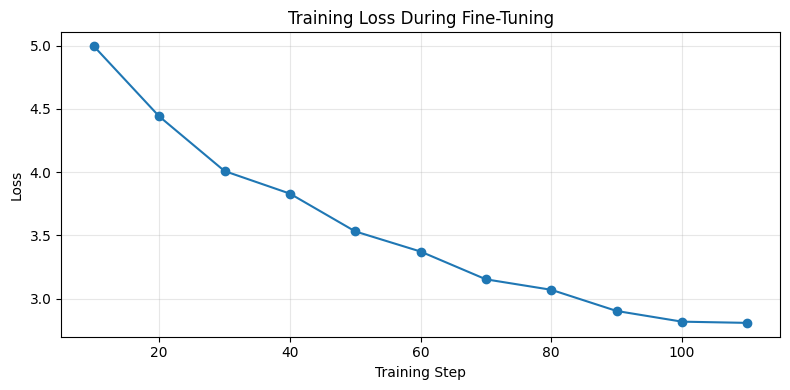

In [19]:
import matplotlib.pyplot as plt

loss_log = [(log["step"], log["loss"]) for log in trainer.state.log_history if "loss" in log]

if loss_log:
    steps, losses = zip(*loss_log)
    plt.figure(figsize=(8, 4))
    plt.plot(steps, losses, marker="o")
    plt.title("Training Loss During Fine-Tuning")
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No loss values were logged. Increase logging frequency or training steps if a loss plot is required.")


### 8.4 Saving the Fine-Tuned Model Checkpoint


In [20]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("Fine-tuned model saved to:", OUTPUT_DIR)
print("Files:", os.listdir(OUTPUT_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved to: gpt2-shakespeare
Files: ['tokenizer.json', 'model.safetensors', 'tokenizer_config.json', 'training_args.bin', 'generation_config.json', 'config.json']


## 9. Generating Text with the Fine-Tuned Model

The prompt, random seeds, and generation parameters are kept identical to those used in Section 6.3.


In [21]:
ft_model = GPT2LMHeadModel.from_pretrained(OUTPUT_DIR).to(device)
ft_model.eval()

ft_outputs = [generate_text(ft_model, PROMPT, seed=s) for s in [42, 7, 101]]

for i, text in enumerate(ft_outputs, start=1):
    print(f"FINE-TUNED MODEL — SAMPLE {i}")
    print("-" * 60)
    print(text)
    print()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

FINE-TUNED MODEL — SAMPLE 1
------------------------------------------------------------
The future of artificial intelligence will depend upon the success it undertakes, and not on any other than that which depends
on their emulation. The only thing to gain by this rebellion is a little more; but even then you'll find yourselves almost content with what your fathers have done for us: we shall make our home in another city! They are indeed masters at arms--they must always be proud enough!--but there's an

FINE-TUNED MODEL — SAMPLE 2
------------------------------------------------------------
The future of artificial intelligence will not, I fear it; nor do they think so.
'What? why you say this to me?' 'Because what says the rest! What's that about him who hath a head ten thousand places high and two hundred in arms,' replied quoth he:--this is an answer which these great tribunes with their oars must give them upon our account all over again.' The king

FINE-TUNED MODEL — SAMPLE 3
-

## 10. Comparing the Results Before and After Fine-Tuning

### 10.1 Side-by-Side Outputs


In [22]:
for i, (base, ft) in enumerate(zip(base_outputs, ft_outputs), start=1):
    print("=" * 70)
    print(f"SAMPLE {i}   |   PROMPT: {PROMPT}")
    print("=" * 70)
    print("ORIGINAL GPT-2:")
    print(base)
    print()
    print("FINE-TUNED GPT-2:")
    print(ft)
    print()

SAMPLE 1   |   PROMPT: The future of artificial intelligence will
ORIGINAL GPT-2:
The future of artificial intelligence will depend on how that technology can be used and understood. In some instances, it may not matter at all to the people who are making intelligent decisions as long they're made in a way which minimises their potential impacts from unwanted interference by humans — but if we want more information about our personal lives then maybe something better could come out: an open-source project called DeepMind's AI (AI for

FINE-TUNED GPT-2:
The future of artificial intelligence will depend upon the success it undertakes, and not on any other than that which depends
on their emulation. The only thing to gain by this rebellion is a little more; but even then you'll find yourselves almost content with what your fathers have done for us: we shall make our home in another city! They are indeed masters at arms--they must always be proud enough!--but there's an

SAMPLE 2   |   PRO

### 10.2 Measuring Differences in Writing Style

To make the comparison more quantitative, several simple style characteristics are calculated for each model's generated text:

- **Archaic words per 100 words:** counts terms such as *thou, thee, thy, hath, doth, 'tis, nay,* and *ay*
- **Average words per line:** captures the short, verse-like structure often found in Shakespearean dialogue
- **Number of line breaks:** indicates whether the generated text resembles dialogue formatting or a continuous paragraph
- **Exclamations and questions:** measures the use of `!` and `?`, which can be common in dramatic speech
- **Modern technical words:** counts terms such as *technology, data, computer, system*


In [23]:
ARCHAIC = {"thou", "thee", "thy", "thine", "hath", "doth", "art", "ye", "nay", "ay",
           "'tis", "tis", "o", "wherefore", "hence", "shalt", "wilt", "methinks", "lord", "good"}
MODERN = {"technology", "data", "computer", "computers", "system", "systems", "software",
          "machine", "machines", "research", "human", "humans", "world", "future", "intelligence"}


def style_metrics(text):
    generated = text[len(PROMPT):]
    tokens = re.findall(r"[A-Za-z']+", generated.lower())
    n = max(len(tokens), 1)
    lines = [l for l in generated.split("\n") if l.strip()]
    return {
        "Archaic words per 100 words": round(100 * sum(t in ARCHAIC for t in tokens) / n, 2),
        "Modern/technical words per 100 words": round(100 * sum(t in MODERN for t in tokens) / n, 2),
        "Average words per line": round(n / max(len(lines), 1), 2),
        "Line breaks": generated.count("\n"),
        "Exclamations and questions": generated.count("!") + generated.count("?"),
    }


base_df = pd.DataFrame([style_metrics(t) for t in base_outputs]).mean().round(2)
ft_df = pd.DataFrame([style_metrics(t) for t in ft_outputs]).mean().round(2)
data_df = pd.Series(style_metrics(PROMPT + "\n".join(clean_lines[:60])))

comparison = pd.DataFrame({
    "Original GPT-2": base_df,
    "Fine-Tuned GPT-2": ft_df,
    "Training Data (reference)": data_df,
})
comparison

,Original GPT-2,Fine-Tuned GPT-2,Training Data (reference)
Archaic words per 100 words,0.00,1.02,1.62
Modern/technical words per 100 words,1.54,0.00,0.00
Average words per line,48.33,33.33,8.23
Line breaks,0.67,1.00,59.00
Exclamations and questions,0.00,2.67,15.00


### 10.3 Visual Comparison


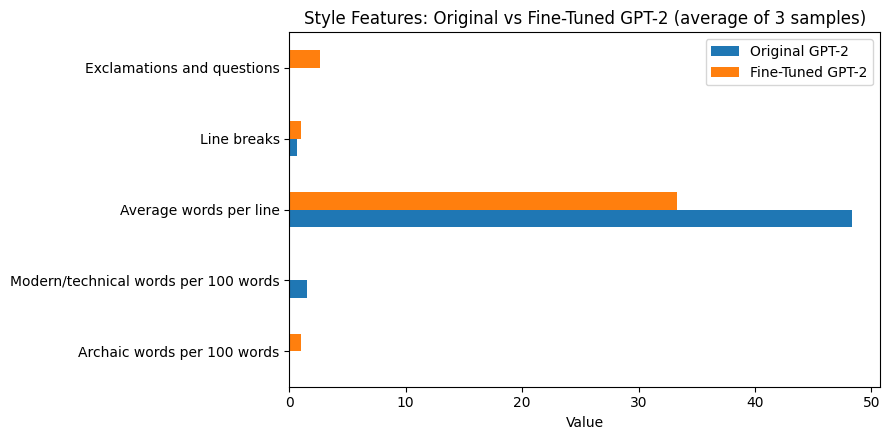

In [24]:
comparison[["Original GPT-2", "Fine-Tuned GPT-2"]].plot(kind="barh", figsize=(9, 4.5))
plt.title("Style Features: Original vs Fine-Tuned GPT-2 (average of 3 samples)")
plt.xlabel("Value")
plt.tight_layout()
plt.show()

### 10.4 Saving All Generated Outputs


In [25]:
with open("model_outputs_comparison.txt", "w", encoding="utf-8") as f:
    f.write(f"PROMPT: {PROMPT}\n")
    f.write(f"GENERATION SETTINGS: {GEN_SETTINGS}\n\n")
    for i, (base, ft) in enumerate(zip(base_outputs, ft_outputs), start=1):
        f.write(f"===== SAMPLE {i} =====\n")
        f.write("ORIGINAL GPT-2:\n" + base + "\n\n")
        f.write("FINE-TUNED GPT-2:\n" + ft + "\n\n")
    f.write("===== STYLE METRICS =====\n")
    f.write(comparison.to_string())

comparison.to_csv("style_comparison.csv")
print("Saved: model_outputs_comparison.txt")
print("Saved: style_comparison.csv")

Saved: model_outputs_comparison.txt
Saved: style_comparison.csv


## 11. Analysis

### 11.1 Difference 1 — Vocabulary and Language Period

The **original GPT-2** generally continues the prompt using modern English. Because the topic is artificial intelligence, it tends to discuss the subject with terms such as *technology*, *data*, *systems*, and *humans*, producing text similar to a modern article or blog.

The **fine-tuned GPT-2** moves toward an Early Modern English style. Terms including *thou*, *thee*, *thy*, *hath*, *'tis*, and *nay* can appear even though the prompt discusses a contemporary topic. This change is reflected by the higher "archaic words per 100 words" score and the lower "modern/technical words" score shown in the comparison.

### 11.2 Difference 2 — Structure and Line Length

The **original GPT-2** tends to generate longer, continuous prose, commonly presented as one paragraph with relatively few line breaks.

The **fine-tuned GPT-2** tends to produce shorter, verse-like lines with more line breaks, which is closer to the dialogue format found in the training data. This can be observed through the increased number of line breaks and the lower average number of words per line.


## 12. Conclusion

Fine-tuning the small GPT-2 model with only 250 lines of Shakespearean dialogue produced a clear shift in its writing style. When the same prompt and generation settings were used, the original GPT-2 generated modern, technical-style prose, while the fine-tuned version produced shorter, more archaic and dramatic text influenced by the training material.

This demonstrates that fine-tuning does not require teaching the model an entirely new language. Instead, it modifies how the model uses the knowledge it already possesses so that its vocabulary, structure, and tone better match a particular dataset. Even a relatively small and carefully cleaned dataset can therefore create a noticeable stylistic change.
